
# VQA on the NDAR paper problem (merged notebook)

This notebook merges the **left-panel Fig. 4 style correlation test** and the **right-panel NDAR vs baselines comparison** into a single flow, but using your **brickwall VQA** instead of QAOA.

What this notebook does:
- uses the paper-style **dense SK Ising problem** with \(J_{ij} \in \{\pm 1\}\),
- keeps your **brickwall VQA** ansatz,
- adds **strong controllable amplitude-damping noise**,
- runs **noisy** and **noiseless** conditions,
- includes an extra **single-instance diagnostic** section inspired by your old `main.ipynb`.

What this notebook does **not** do:
- it is **not** a literal reproduction of the paper, because the paper’s main Fig. 4 is based on **p=1 QAOA**, while this notebook uses your **VQA** ansatz on the **same SK problem**.

Recommended default:
- `gauge_mode = "output_only"` for the main black-box VQA test.
- `pure_damping = True` and nonzero `extra_amp_damp_*` to make the attractor visible.

Run this notebook from inside the `NDAR/` folder of your project so the relative imports work.


In [13]:

import json
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(iterable=None, *args, **kwargs):
        return iterable if iterable is not None else []

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, amplitude_damping_error
from qiskit_ibm_runtime.fake_provider import FakeBrisbane

from quantum.circuit import build_brickwall, build_circuit
from optimizer.adam_spsa import optimize
from ndar.utils import bind_and_run_circuit

plt.rcParams["figure.dpi"] = 130


In [14]:

# ======================================================================================
# CONFIG
# ======================================================================================
PRESETS = {
    "debug": {
        "n_qubits": 10,
        "depth": 1,
        "n_instances": 2,
        "n_gauges": 1,
        "left_shots": 128,
        "left_n_epochs": 8,
        "K": 4,
        "right_n_epochs": 8,
        "right_shots": 128,
        "n_random_gauges": 6,
    },
    "medium": {
        "n_qubits": 10,
        "depth": 1,
        "n_instances": 1,
        "n_gauges": 2,
        "left_shots": 100,
        "left_n_epochs": 10,
        "K": 5,
        "right_n_epochs": 10,
        "right_shots": 256,
        "n_random_gauges": 2,
    },
    "paperish_vqa": {
        "n_qubits": 16,
        "depth": 1,
        "n_instances": 10,
        "n_gauges": 20,
        "left_shots": 256,
        "left_n_epochs": 10,
        "K": 5,
        "right_n_epochs": 10,
        "right_shots": 256,
        "n_random_gauges": 20,
    },
}

preset_name = "medium"
preset = PRESETS[preset_name]

CONFIG = {
    "preset_name": preset_name,
    "seed": 1924,

    # Problem = paper-style dense SK Ising
    "n_qubits": preset["n_qubits"],
    "depth": preset["depth"],

    # Gauge implementation for VQA
    "gauge_mode": "output_only",   # recommended main black-box VQA run
    # alternatives: "none", "sandwich"

    # Left-like experiment
    "n_instances": preset["n_instances"],
    "n_gauges": preset["n_gauges"],
    "left_shots": preset["left_shots"],
    "left_n_epochs": preset["left_n_epochs"],
    "top_fracs": [1.0, 50 / 256, 1 / 256],

    # Right-like experiment
    "K": preset["K"],
    "right_n_epochs": preset["right_n_epochs"],
    "right_shots": preset["right_shots"],
    "n_random_gauges": preset["n_random_gauges"],

    # Optimizer
    "adam_lr": 0.10,
    "adam_beta1": 0.9,
    "adam_beta2": 0.999,
    "adam_eps": 1e-8,
    "spsa_c": 0.15,
    "spsa_gamma": 0.101,

    # Noise
    "use_qiskit_default_noise": False,
    "pure_damping": True,
    "extra_amp_damp_1q": 0.01,
    "extra_amp_damp_2q": 0.05,

    # Which sections to run
    "run_left_panel": True,
    "run_right_panel": True,
    "run_single_instance_diag": True,

    # Output
    "out_dir": "merged_vqa_sk_fig4",
}

CONFIG


{'preset_name': 'medium',
 'seed': 1924,
 'n_qubits': 10,
 'depth': 1,
 'gauge_mode': 'output_only',
 'n_instances': 1,
 'n_gauges': 2,
 'left_shots': 100,
 'left_n_epochs': 10,
 'top_fracs': [1.0, 0.1953125, 0.00390625],
 'K': 5,
 'right_n_epochs': 10,
 'right_shots': 256,
 'n_random_gauges': 2,
 'adam_lr': 0.1,
 'adam_beta1': 0.9,
 'adam_beta2': 0.999,
 'adam_eps': 1e-08,
 'spsa_c': 0.15,
 'spsa_gamma': 0.101,
 'use_qiskit_default_noise': False,
 'pure_damping': True,
 'extra_amp_damp_1q': 0.01,
 'extra_amp_damp_2q': 0.05,
 'run_left_panel': True,
 'run_right_panel': True,
 'run_single_instance_diag': True,
 'out_dir': 'merged_vqa_sk_fig4'}

In [15]:

# ======================================================================================
# BASIC UTILS
# ======================================================================================
def ensure_dir(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path

def save_json(obj, path):
    path = Path(path)
    path.write_text(json.dumps(obj, indent=2, ensure_ascii=False), encoding="utf-8")

def random_bitstring(n_qubits, rng):
    return "".join(rng.choice(["0", "1"], size=n_qubits))

def xor_bitstrings(a, b):
    return "".join("1" if x != y else "0" for x, y in zip(a, b))

def qiskit_to_q0_first(bitstring):
    return bitstring.replace(" ", "")[::-1]

def bitstring_to_spins(bitstring_q0_first):
    return np.array([1 if b == "0" else -1 for b in bitstring_q0_first], dtype=float)

def energy_of_bitstring(bitstring_q0_first, constant_term, zz_terms):
    s = bitstring_to_spins(bitstring_q0_first)
    energy = float(constant_term)
    for i, j, coeff in zz_terms:
        energy += float(coeff) * s[i] * s[j]
    return float(energy)

def ratio_of_bitstring(bitstring_q0_first, constant_term, zz_terms, E_GS_exact):
    return float(energy_of_bitstring(bitstring_q0_first, constant_term, zz_terms) / E_GS_exact)

def summarize_top_fracs(ratios, top_fracs):
    ratios = np.asarray(ratios, dtype=float)
    ratios_sorted = np.sort(ratios)[::-1]  # descending = better AR
    out = {}
    n = len(ratios_sorted)
    for frac in top_fracs:
        k = max(1, int(np.ceil(frac * n)))
        out[f"top_{frac:.6f}"] = float(np.mean(ratios_sorted[:k]))
    out["mean"] = float(np.mean(ratios_sorted))
    out["best"] = float(np.max(ratios_sorted))
    return out

def rankdata_average(x):
    x = np.asarray(x, dtype=float)
    order = np.argsort(x, kind="mergesort")
    ranks = np.empty(len(x), dtype=float)
    i = 0
    while i < len(x):
        j = i
        while j + 1 < len(x) and x[order[j + 1]] == x[order[i]]:
            j += 1
        avg_rank = 0.5 * (i + j) + 1.0
        for k in range(i, j + 1):
            ranks[order[k]] = avg_rank
        i = j + 1
    return ranks

def pearson_corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 2 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])

def spearman_corr(x, y):
    rx = rankdata_average(x)
    ry = rankdata_average(y)
    return pearson_corr(rx, ry)

def build_sk_problem_terms(n_qubits, seed_instance):
    rng = np.random.default_rng(seed_instance)
    zz_terms = []
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            Jij = float(rng.choice([-1.0, 1.0]))
            zz_terms.append((i, j, Jij))
    return 0.0, zz_terms

def update_terms_by_gauge(constant_term, zz_terms, bitstring_q0_first):
    signs = np.array([-1.0 if b == "1" else 1.0 for b in bitstring_q0_first], dtype=float)
    new_terms = []
    for i, j, coeff in zz_terms:
        new_terms.append((i, j, float(coeff * signs[i] * signs[j])))
    return float(constant_term), new_terms

def brute_force_ground_energy(n_qubits, constant_term, zz_terms):
    best_e = None
    best_states = []
    for state in range(2 ** n_qubits):
        bs = format(state, f"0{n_qubits}b")[::-1]  # q0-first
        e = energy_of_bitstring(bs, constant_term, zz_terms)
        if (best_e is None) or (e < best_e - 1e-12):
            best_e = e
            best_states = [bs]
        elif abs(e - best_e) <= 1e-12:
            best_states.append(bs)
    return float(best_e), best_states

def sample_theta_sk_full(
    *,
    n_qubits,
    E_GS_exact,
    theta,
    iter_label,
    transpiled_measured_template,
    ansatz_params,
    simulator,
    shots,
    seed_simulator,
    H_constant_term,
    H_zz_terms,
):
    result = bind_and_run_circuit(
        theta=theta,
        transpiled_measured_template=transpiled_measured_template,
        ansatz_params=ansatz_params,
        simulator=simulator,
        shots=shots,
        seed_simulator=seed_simulator,
    )
    memory = result.get_memory()

    rows = []
    energies = []
    ratios = []

    for k, raw_bs in enumerate(memory):
        bs_q0 = qiskit_to_q0_first(raw_bs)
        energy = energy_of_bitstring(bs_q0, H_constant_term, H_zz_terms)
        ratio = energy / E_GS_exact
        rows.append(
            {
                "label": iter_label,
                "shot": k,
                "bitstring_qiskit": raw_bs.replace(" ", ""),
                "bitstring_q0_first": bs_q0,
                "hamiltonian_value": energy,
                "approx_ratio": ratio,
            }
        )
        energies.append(energy)
        ratios.append(ratio)

    df_shots = pd.DataFrame(rows)
    min_energy = float(np.min(energies))
    expected_energy = float(np.mean(energies))
    best_idx = int(np.argmin(energies))
    best_bitstring = df_shots.iloc[best_idx]["bitstring_q0_first"]

    best_ratio = min_energy / E_GS_exact
    expected_ratio = expected_energy / E_GS_exact

    zero_bitstring = "0" * n_qubits
    zero_energy = energy_of_bitstring(zero_bitstring, H_constant_term, H_zz_terms)
    zero_ratio = zero_energy / E_GS_exact

    return {
        "df_shots": df_shots,
        "bitstrings_q0_first": df_shots["bitstring_q0_first"].tolist(),
        "bitstrings_qiskit": df_shots["bitstring_qiskit"].tolist(),
        "best_bitstring": best_bitstring,
        "min_energy": min_energy,
        "expected_energy": expected_energy,
        "best_ratio": float(best_ratio),
        "expected_ratio": float(expected_ratio),
        "zero_ratio": float(zero_ratio),
        "ratios": np.array(ratios, dtype=float),
    }

def extract_bitstrings(sample_result):
    if "bitstrings_q0_first" in sample_result:
        return list(sample_result["bitstrings_q0_first"])
    if "df_shots" in sample_result:
        return sample_result["df_shots"]["bitstring_q0_first"].tolist()
    raise KeyError(f"Available keys: {list(sample_result.keys())}")

def best_bitstring_under_original_H(bitstrings, H0_constant, H0_terms):
    energies = [energy_of_bitstring(bs, H0_constant, H0_terms) for bs in bitstrings]
    idx = int(np.argmin(energies))
    return bitstrings[idx], float(energies[idx])

def summarize_condition(df_condition):
    rows = []
    for frac in CONFIG["top_fracs"]:
        frac_col = f"optimized_ratio_top_{frac:.6f}"
        rows.append({
            "quantile": frac,
            "pearson_r": pearson_corr(df_condition["attractor_ratio"], df_condition[frac_col]),
            "spearman_rho": spearman_corr(df_condition["attractor_ratio"], df_condition[frac_col]),
            "mean_attractor_ratio": float(df_condition["attractor_ratio"].mean()),
            "mean_optimized_ratio": float(df_condition[frac_col].mean()),
        })
    return pd.DataFrame(rows)


In [16]:

# ======================================================================================
# NOISE + PROBLEM BUILDERS
# ======================================================================================
def build_noise_model(fake_backend, extra_amp_damp_1q=0.0, extra_amp_damp_2q=0.0, pure_damping=False):
    if pure_damping:
        noise_model = NoiseModel()
        basis = set(fake_backend.operation_names)
    else:
        noise_model = NoiseModel.from_backend(fake_backend)
        basis = set(noise_model.basis_gates)

    one_q_gates = [g for g in ["id", "rz", "sx", "x", "rx", "ry"] if g in basis]
    two_q_gates = [g for g in ["cx", "ecr"] if g in basis]

    if extra_amp_damp_1q > 0.0:
        err1 = amplitude_damping_error(extra_amp_damp_1q)
        for g in one_q_gates:
            noise_model.add_all_qubit_quantum_error(err1, g)

    if extra_amp_damp_2q > 0.0:
        err2 = amplitude_damping_error(extra_amp_damp_2q).tensor(
            amplitude_damping_error(extra_amp_damp_2q)
        )
        for g in two_q_gates:
            noise_model.add_all_qubit_quantum_error(err2, g)

    return noise_model

def get_simulator_vqa_sk(n_qubits, noisy=True, cfg=None):
    fake_backend = FakeBrisbane()
    if n_qubits > fake_backend.num_qubits:
        raise ValueError(
            f"n_qubits={n_qubits} exceeds selected backend "
            f"({fake_backend.name}, {fake_backend.num_qubits} qubits)."
        )

    transpile_backend = fake_backend

    if not noisy:
        run_backend = AerSimulator()
    else:
        if cfg["use_qiskit_default_noise"] and not cfg["pure_damping"]:
            if cfg["extra_amp_damp_1q"] == 0.0 and cfg["extra_amp_damp_2q"] == 0.0:
                run_backend = AerSimulator.from_backend(fake_backend)
            else:
                noise_model = build_noise_model(
                    fake_backend,
                    extra_amp_damp_1q=cfg["extra_amp_damp_1q"],
                    extra_amp_damp_2q=cfg["extra_amp_damp_2q"],
                    pure_damping=False,
                )
                run_backend = AerSimulator(
                    noise_model=noise_model,
                    basis_gates=noise_model.basis_gates,
                )
        else:
            noise_model = build_noise_model(
                fake_backend,
                extra_amp_damp_1q=cfg["extra_amp_damp_1q"],
                extra_amp_damp_2q=cfg["extra_amp_damp_2q"],
                pure_damping=cfg["pure_damping"],
            )
            run_backend = AerSimulator(
                noise_model=noise_model,
                basis_gates=noise_model.basis_gates,
            )

    return run_backend, transpile_backend

def build_problem(cfg, seed_instance):
    constant_term, zz_terms = build_sk_problem_terms(cfg["n_qubits"], seed_instance)

    ansatz, params = build_brickwall(cfg["n_qubits"], cfg["depth"])

    E_GS_exact, exact_ground_states = brute_force_ground_energy(
        cfg["n_qubits"], constant_term, zz_terms
    )

    rng = np.random.default_rng(seed_instance)
    theta_init = rng.uniform(-0.1, 0.1, size=len(params))

    return {
        "ansatz": ansatz,
        "params": params,
        "H_constant": constant_term,
        "H_terms": zz_terms,
        "E_GS_exact": E_GS_exact,
        "exact_ground_states": exact_ground_states,
        "theta_init": theta_init,
    }

def build_transpiled_circuit(problem, cfg, transpile_backend, seed_instance, gauge_bitstring=None):
    if gauge_bitstring is None:
        return build_circuit(
            n_qubits=cfg["n_qubits"],
            ansatz=problem["ansatz"],
            transpile_backend=transpile_backend,
            seed=seed_instance,
            gauge_bitstring_q0_first=None,
            gauge_mode="none",
        )

    return build_circuit(
        n_qubits=cfg["n_qubits"],
        ansatz=problem["ansatz"],
        transpile_backend=transpile_backend,
        seed=seed_instance,
        gauge_bitstring_q0_first=gauge_bitstring,
        gauge_mode=cfg["gauge_mode"],
    )

def identity_hamming_weight_diagnostic(cfg, noisy, shots=2000):
    simulator, transpile_backend = get_simulator_vqa_sk(
        n_qubits=cfg["n_qubits"], noisy=noisy, cfg=cfg
    )
    from qiskit import QuantumCircuit, transpile

    qc = QuantumCircuit(cfg["n_qubits"])
    qc.measure_all()
    tqc = transpile(qc, backend=transpile_backend, optimization_level=1, seed_transpiler=1234)

    result = simulator.run(
        tqc, shots=shots, memory=True, seed_simulator=12345
    ).result()

    mem = [qiskit_to_q0_first(m) for m in result.get_memory()]
    hws = np.array([sum(c == "1" for c in b) for b in mem], dtype=float)
    return {
        "mean_hw": float(hws.mean()),
        "std_hw": float(hws.std()),
        "hist": hws,
    }


In [17]:

# ======================================================================================
# CORE RUNNERS
# ======================================================================================
def run_single_train_and_sample(
    *,
    label,
    theta_init,
    transpiled_circuit,
    params,
    simulator,
    shots,
    H_constant,
    H_terms,
    E_GS_exact,
    seed_base,
    n_epochs,
    cfg,
):
    train_result = optimize(
        label=label,
        theta_init=theta_init.copy(),
        transpiled_measured_template=transpiled_circuit,
        ansatz_params=params,
        simulator=simulator,
        shots=shots,
        H_constant_term=H_constant,
        H_zz_terms=H_terms,
        out_dir_sub=None,
        seed_base=seed_base,
        n_epochs=n_epochs,
        lr=cfg["adam_lr"],
        beta1=cfg["adam_beta1"],
        beta2=cfg["adam_beta2"],
        eps=cfg["adam_eps"],
        spsa_c=cfg["spsa_c"],
        spsa_gamma=cfg["spsa_gamma"],
    )

    theta_best = train_result["theta_best"].copy()

    sample_result = sample_theta_sk_full(
        n_qubits=cfg["n_qubits"],
        E_GS_exact=E_GS_exact,
        theta=theta_best,
        iter_label=label,
        transpiled_measured_template=transpiled_circuit,
        ansatz_params=params,
        simulator=simulator,
        shots=shots,
        seed_simulator=seed_base + 123456,
        H_constant_term=H_constant,
        H_zz_terms=H_terms,
    )

    return train_result, sample_result

def run_single_vqa_final_distribution(
    *,
    label,
    theta_init,
    transpiled_circuit,
    params,
    simulator,
    shots,
    H_constant,
    H_terms,
    E_GS_exact,
    seed_base,
    cfg,
):
    train_result, sample_result = run_single_train_and_sample(
        label=label,
        theta_init=theta_init,
        transpiled_circuit=transpiled_circuit,
        params=params,
        simulator=simulator,
        shots=shots,
        H_constant=H_constant,
        H_terms=H_terms,
        E_GS_exact=E_GS_exact,
        seed_base=seed_base,
        n_epochs=cfg["left_n_epochs"],
        cfg=cfg,
    )
    return {
        "train_result": train_result,
        "sample_result": sample_result,
    }

def run_left_like(cfg, simulator, transpile_backend, out_dir, condition_name):
    rows = []

    inst_iter = tqdm(range(cfg["n_instances"]), desc=f"{condition_name} left instances")
    for inst_id in inst_iter:
        seed_instance = cfg["seed"] + 10000 * inst_id
        rng_inst = np.random.default_rng(seed_instance)

        problem = build_problem(cfg, seed_instance)
        H0_constant = problem["H_constant"]
        H0_terms = problem["H_terms"]
        E_GS_exact = problem["E_GS_exact"]
        theta_init_shared = problem["theta_init"].copy()

        optimizer_seed_for_instance = cfg["seed"] + 500000 + inst_id

        gauge_iter = tqdm(range(cfg["n_gauges"]), desc=f"inst {inst_id:02d} gauges", leave=False)
        for gauge_id in gauge_iter:
            y = random_bitstring(cfg["n_qubits"], rng_inst)

            Hy_constant, Hy_terms = update_terms_by_gauge(H0_constant, H0_terms, y)

            transpiled_circuit_y = build_transpiled_circuit(
                problem=problem,
                cfg=cfg,
                transpile_backend=transpile_backend,
                seed_instance=seed_instance,
                gauge_bitstring=y,
            )

            attractor_ratio = ratio_of_bitstring(
                bitstring_q0_first=y,
                constant_term=H0_constant,
                zz_terms=H0_terms,
                E_GS_exact=E_GS_exact,
            )

            res = run_single_vqa_final_distribution(
                label=f"{condition_name}_inst_{inst_id}_gauge_{gauge_id}",
                theta_init=theta_init_shared,
                transpiled_circuit=transpiled_circuit_y,
                params=problem["params"],
                simulator=simulator,
                shots=cfg["left_shots"],
                H_constant=Hy_constant,
                H_terms=Hy_terms,
                E_GS_exact=E_GS_exact,
                seed_base=optimizer_seed_for_instance,
                cfg=cfg,
            )

            ratios = np.asarray(res["sample_result"]["ratios"], dtype=float)
            summary = summarize_top_fracs(ratios, cfg["top_fracs"])

            row = {
                "condition": condition_name,
                "instance_id": inst_id,
                "gauge_id": gauge_id,
                "gauge_bitstring": y,
                "attractor_ratio": attractor_ratio,
                "optimized_ratio_mean_all": summary["mean"],
                "optimized_ratio_best_sample": summary["best"],
            }

            for frac in cfg["top_fracs"]:
                row[f"optimized_ratio_top_{frac:.6f}"] = summary[f"top_{frac:.6f}"]

            rows.append(row)

    df = pd.DataFrame(rows)
    df.to_csv(out_dir / f"{condition_name}_left_data.csv", index=False)

    summary_df = summarize_condition(df)
    summary_df.to_csv(out_dir / f"{condition_name}_left_summary.csv", index=False)

    return df, summary_df

def run_plain_vqa(problem, cfg, simulator, transpile_backend, seed_instance, optimizer_seed):
    H0_constant = problem["H_constant"]
    H0_terms = problem["H_terms"]
    E_GS_exact = problem["E_GS_exact"]

    circuit = build_transpiled_circuit(
        problem=problem,
        cfg=cfg,
        transpile_backend=transpile_backend,
        seed_instance=seed_instance,
        gauge_bitstring=None,
    )

    rows = []
    current_best_energy = np.inf

    for k in range(1, cfg["K"] + 1):
        _, sample_result = run_single_train_and_sample(
            label=f"plain_vqa_budget_{k}",
            theta_init=problem["theta_init"],
            transpiled_circuit=circuit,
            params=problem["params"],
            simulator=simulator,
            shots=cfg["right_shots"],
            H_constant=H0_constant,
            H_terms=H0_terms,
            E_GS_exact=E_GS_exact,
            seed_base=optimizer_seed,
            n_epochs=k * cfg["right_n_epochs"],
            cfg=cfg,
        )

        bitstrings = extract_bitstrings(sample_result)
        best_bs, best_energy = best_bitstring_under_original_H(
            bitstrings, H0_constant, H0_terms
        )
        current_best_energy = min(current_best_energy, best_energy)

        rows.append({
            "method": "plain_vqa",
            "outer_iter": k,
            "best_energy_so_far": current_best_energy,
            "best_ratio_so_far": current_best_energy / E_GS_exact,
            "current_best_bitstring": best_bs,
            "current_gauge": "0" * cfg["n_qubits"],
        })

    return rows

def run_multistart(problem, cfg, simulator, transpile_backend, seed_instance, optimizer_seed):
    H0_constant = problem["H_constant"]
    H0_terms = problem["H_terms"]
    E_GS_exact = problem["E_GS_exact"]

    circuit = build_transpiled_circuit(
        problem=problem,
        cfg=cfg,
        transpile_backend=transpile_backend,
        seed_instance=seed_instance,
        gauge_bitstring=None,
    )

    rng = np.random.default_rng(seed_instance + 777)
    rows = []
    current_best_energy = np.inf

    for k in range(1, cfg["K"] + 1):
        theta0 = rng.uniform(-0.1, 0.1, size=len(problem["params"]))
        _, sample_result = run_single_train_and_sample(
            label=f"multistart_{k}",
            theta_init=theta0,
            transpiled_circuit=circuit,
            params=problem["params"],
            simulator=simulator,
            shots=cfg["right_shots"],
            H_constant=H0_constant,
            H_terms=H0_terms,
            E_GS_exact=E_GS_exact,
            seed_base=optimizer_seed + 10000 * k,
            n_epochs=cfg["right_n_epochs"],
            cfg=cfg,
        )

        bitstrings = extract_bitstrings(sample_result)
        best_bs, best_energy = best_bitstring_under_original_H(
            bitstrings, H0_constant, H0_terms
        )
        current_best_energy = min(current_best_energy, best_energy)

        rows.append({
            "method": "multistart",
            "outer_iter": k,
            "best_energy_so_far": current_best_energy,
            "best_ratio_so_far": current_best_energy / E_GS_exact,
            "current_best_bitstring": best_bs,
            "current_gauge": "0" * cfg["n_qubits"],
        })

    return rows

def run_random_remap(problem, cfg, simulator, transpile_backend, seed_instance, optimizer_seed):
    H0_constant = problem["H_constant"]
    H0_terms = problem["H_terms"]
    E_GS_exact = problem["E_GS_exact"]

    rng = np.random.default_rng(seed_instance + 2024)
    rows = []
    current_best_energy = np.inf

    for k in range(1, cfg["K"] + 1):
        g = random_bitstring(cfg["n_qubits"], rng)
        Hg_constant, Hg_terms = update_terms_by_gauge(H0_constant, H0_terms, g)

        circuit_g = build_transpiled_circuit(
            problem=problem,
            cfg=cfg,
            transpile_backend=transpile_backend,
            seed_instance=seed_instance,
            gauge_bitstring=g,
        )

        _, sample_result = run_single_train_and_sample(
            label=f"random_remap_{k}",
            theta_init=problem["theta_init"],
            transpiled_circuit=circuit_g,
            params=problem["params"],
            simulator=simulator,
            shots=cfg["right_shots"],
            H_constant=Hg_constant,
            H_terms=Hg_terms,
            E_GS_exact=E_GS_exact,
            seed_base=optimizer_seed,
            n_epochs=cfg["right_n_epochs"],
            cfg=cfg,
        )

        bitstrings = extract_bitstrings(sample_result)
        if cfg["gauge_mode"] == "output_only":
            bitstrings_original = [xor_bitstrings(bs, g) for bs in bitstrings]
        else:
            bitstrings_original = bitstrings

        best_bs_original, best_energy = best_bitstring_under_original_H(
            bitstrings_original, H0_constant, H0_terms
        )
        current_best_energy = min(current_best_energy, best_energy)

        rows.append({
            "method": "random_remap",
            "outer_iter": k,
            "best_energy_so_far": current_best_energy,
            "best_ratio_so_far": current_best_energy / E_GS_exact,
            "current_best_bitstring": best_bs_original,
            "current_gauge": g,
        })

    return rows

def run_ndar(problem, cfg, simulator, transpile_backend, seed_instance, optimizer_seed):
    H0_constant = problem["H_constant"]
    H0_terms = problem["H_terms"]
    E_GS_exact = problem["E_GS_exact"]

    g = "0" * cfg["n_qubits"]
    current_best_energy = np.inf
    rows = []
    ratio_distributions = []
    best_ratios = []
    attractor_ratios = []

    for k in range(1, cfg["K"] + 1):
        Hg_constant, Hg_terms = update_terms_by_gauge(H0_constant, H0_terms, g)

        circuit_g = build_transpiled_circuit(
            problem=problem,
            cfg=cfg,
            transpile_backend=transpile_backend,
            seed_instance=seed_instance,
            gauge_bitstring=g,
        )

        _, sample_result = run_single_train_and_sample(
            label=f"ndar_{k}",
            theta_init=problem["theta_init"],
            transpiled_circuit=circuit_g,
            params=problem["params"],
            simulator=simulator,
            shots=cfg["right_shots"],
            H_constant=Hg_constant,
            H_terms=Hg_terms,
            E_GS_exact=E_GS_exact,
            seed_base=optimizer_seed,
            n_epochs=cfg["right_n_epochs"],
            cfg=cfg,
        )

        bitstrings = extract_bitstrings(sample_result)
        if cfg["gauge_mode"] == "output_only":
            bitstrings_original = [xor_bitstrings(bs, g) for bs in bitstrings]
        else:
            bitstrings_original = bitstrings

        best_bs_original, best_energy = best_bitstring_under_original_H(
            bitstrings_original, H0_constant, H0_terms
        )
        current_best_energy = min(current_best_energy, best_energy)

        ratios_original = np.array(
            [ratio_of_bitstring(bs, H0_constant, H0_terms, E_GS_exact) for bs in bitstrings_original],
            dtype=float,
        )
        ratio_distributions.append(ratios_original)
        best_ratios.append(float(np.max(ratios_original)))
        attractor_ratios.append(
            ratio_of_bitstring(g, H0_constant, H0_terms, E_GS_exact)
        )

        g = xor_bitstrings(g, best_bs_original)

        rows.append({
            "method": "ndar",
            "outer_iter": k,
            "best_energy_so_far": current_best_energy,
            "best_ratio_so_far": current_best_energy / E_GS_exact,
            "current_best_bitstring": best_bs_original,
            "current_gauge": g,
        })

    return rows, ratio_distributions, best_ratios, attractor_ratios

def run_random_uniform(problem, cfg, seed_instance):
    H0_constant = problem["H_constant"]
    H0_terms = problem["H_terms"]
    E_GS_exact = problem["E_GS_exact"]
    rng = np.random.default_rng(seed_instance + 9090)

    rows = []
    current_best_energy = np.inf
    for k in range(1, cfg["K"] + 1):
        n_samples = k * cfg["right_n_epochs"] * cfg["right_shots"]
        for _ in range(n_samples):
            bs = random_bitstring(cfg["n_qubits"], rng)
            e = energy_of_bitstring(bs, H0_constant, H0_terms)
            current_best_energy = min(current_best_energy, e)

        rows.append({
            "method": "random_uniform",
            "outer_iter": k,
            "best_energy_so_far": current_best_energy,
            "best_ratio_so_far": current_best_energy / E_GS_exact,
            "current_best_bitstring": None,
            "current_gauge": None,
        })
    return rows


noisy left instances:   0%|          | 0/1 [00:00<?, ?it/s]

noisy_inst_0_gauge_0 | epoch=001 | loss=0.460000 | best=0.460000 | grad_norm=3.875851
noisy_inst_0_gauge_0 | epoch=002 | loss=0.440000 | best=0.440000 | grad_norm=6.715016
noisy_inst_0_gauge_0 | epoch=003 | loss=0.300000 | best=0.300000 | grad_norm=3.664424
noisy_inst_0_gauge_0 | epoch=004 | loss=0.220000 | best=0.220000 | grad_norm=5.487213
noisy_inst_0_gauge_0 | epoch=005 | loss=0.160000 | best=0.160000 | grad_norm=4.910749
noisy_inst_0_gauge_0 | epoch=006 | loss=0.080000 | best=0.080000 | grad_norm=1.071861
noisy_inst_0_gauge_0 | epoch=007 | loss=0.080000 | best=0.080000 | grad_norm=4.717610
noisy_inst_0_gauge_0 | epoch=008 | loss=-0.020000 | best=-0.020000 | grad_norm=4.046025
noisy_inst_0_gauge_0 | epoch=009 | loss=-0.240000 | best=-0.240000 | grad_norm=9.305554
noisy_inst_0_gauge_0 | epoch=010 | loss=-0.480000 | best=-0.480000 | grad_norm=29.343934


noisy_inst_0_gauge_1 | epoch=001 | loss=0.280000 | best=0.280000 | grad_norm=1.192570
noisy_inst_0_gauge_1 | epoch=002 | loss=0.280000 | best=0.280000 | grad_norm=4.156915
noisy_inst_0_gauge_1 | epoch=003 | loss=0.380000 | best=0.280000 | grad_norm=0.666259
noisy_inst_0_gauge_1 | epoch=004 | loss=0.400000 | best=0.280000 | grad_norm=1.371803
noisy_inst_0_gauge_1 | epoch=005 | loss=0.140000 | best=0.140000 | grad_norm=2.806142
noisy_inst_0_gauge_1 | epoch=006 | loss=0.100000 | best=0.100000 | grad_norm=1.786434
noisy_inst_0_gauge_1 | epoch=007 | loss=0.360000 | best=0.100000 | grad_norm=6.169182
noisy_inst_0_gauge_1 | epoch=008 | loss=0.020000 | best=0.020000 | grad_norm=5.149486
noisy_inst_0_gauge_1 | epoch=009 | loss=-0.040000 | best=-0.040000 | grad_norm=1.116666


noisy left instances: 100%|██████████| 1/1 [00:01<00:00,  1.03s/it]


noisy_inst_0_gauge_1 | epoch=010 | loss=-0.200000 | best=-0.200000 | grad_norm=14.295763


noiseless left instances:   0%|          | 0/1 [00:00<?, ?it/s]

noiseless_inst_0_gauge_0 | epoch=001 | loss=1.040000 | best=1.040000 | grad_norm=0.596285
noiseless_inst_0_gauge_0 | epoch=002 | loss=0.880000 | best=0.880000 | grad_norm=4.796440
noiseless_inst_0_gauge_0 | epoch=003 | loss=1.040000 | best=0.880000 | grad_norm=9.660753
noiseless_inst_0_gauge_0 | epoch=004 | loss=0.700000 | best=0.700000 | grad_norm=3.086557
noiseless_inst_0_gauge_0 | epoch=005 | loss=1.060000 | best=0.700000 | grad_norm=1.052303
noiseless_inst_0_gauge_0 | epoch=006 | loss=1.040000 | best=0.700000 | grad_norm=2.143721
noiseless_inst_0_gauge_0 | epoch=007 | loss=0.620000 | best=0.620000 | grad_norm=10.161005
noiseless_inst_0_gauge_0 | epoch=008 | loss=0.480000 | best=0.480000 | grad_norm=14.712817
noiseless_inst_0_gauge_0 | epoch=009 | loss=0.060000 | best=0.060000 | grad_norm=13.399998
noiseless_inst_0_gauge_0 | epoch=010 | loss=0.460000 | best=0.060000 | grad_norm=5.643064
noiseless_inst_0_gauge_1 | epoch=001 | loss=0.760000 | best=0.760000 | grad_norm=0.894427
noisele

noiseless left instances: 100%|██████████| 1/1 [00:00<00:00,  6.98it/s]


noiseless_inst_0_gauge_1 | epoch=009 | loss=-0.060000 | best=-0.060000 | grad_norm=26.055552
noiseless_inst_0_gauge_1 | epoch=010 | loss=-0.120000 | best=-0.120000 | grad_norm=15.800580


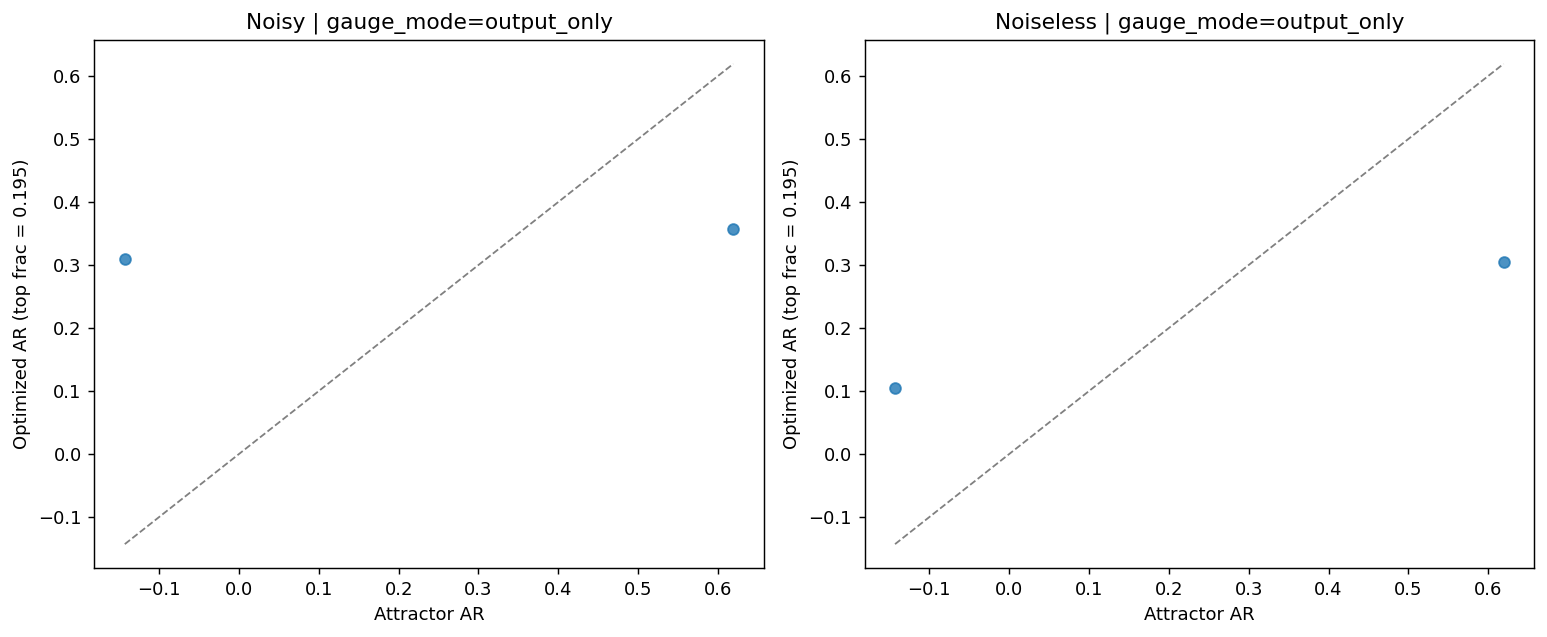

noisy right instances:   0%|          | 0/1 [00:00<?, ?it/s]

plain_vqa_budget_1 | epoch=001 | loss=0.140625 | best=0.140625 | grad_norm=0.931695
plain_vqa_budget_1 | epoch=002 | loss=-0.046875 | best=-0.046875 | grad_norm=2.623053
plain_vqa_budget_1 | epoch=003 | loss=0.101562 | best=-0.046875 | grad_norm=1.171158
plain_vqa_budget_1 | epoch=004 | loss=0.062500 | best=-0.046875 | grad_norm=2.947233
plain_vqa_budget_1 | epoch=005 | loss=-0.132812 | best=-0.132812 | grad_norm=1.370187
plain_vqa_budget_1 | epoch=006 | loss=-0.296875 | best=-0.296875 | grad_norm=2.512173
plain_vqa_budget_1 | epoch=007 | loss=-0.273438 | best=-0.296875 | grad_norm=12.190938
plain_vqa_budget_1 | epoch=008 | loss=-0.484375 | best=-0.484375 | grad_norm=11.207028
plain_vqa_budget_1 | epoch=009 | loss=-0.539062 | best=-0.539062 | grad_norm=6.833766
plain_vqa_budget_1 | epoch=010 | loss=-0.687500 | best=-0.687500 | grad_norm=16.899802
plain_vqa_budget_2 | epoch=001 | loss=0.140625 | best=0.140625 | grad_norm=0.931695
plain_vqa_budget_2 | epoch=002 | loss=-0.046875 | best=-0

noiseless right instances:   0%|          | 0/1 [00:00<?, ?it/s]

plain_vqa_budget_1 | epoch=001 | loss=0.859375 | best=0.859375 | grad_norm=1.746928
plain_vqa_budget_1 | epoch=002 | loss=0.859375 | best=0.859375 | grad_norm=4.746477
plain_vqa_budget_1 | epoch=003 | loss=0.734375 | best=0.734375 | grad_norm=2.082059
plain_vqa_budget_1 | epoch=004 | loss=0.585938 | best=0.585938 | grad_norm=4.554815
plain_vqa_budget_1 | epoch=005 | loss=0.968750 | best=0.585938 | grad_norm=4.247579
plain_vqa_budget_1 | epoch=006 | loss=0.781250 | best=0.585938 | grad_norm=4.884781
plain_vqa_budget_1 | epoch=007 | loss=0.656250 | best=0.585938 | grad_norm=7.513020
plain_vqa_budget_1 | epoch=008 | loss=0.531250 | best=0.531250 | grad_norm=3.591996
plain_vqa_budget_1 | epoch=009 | loss=0.265625 | best=0.265625 | grad_norm=19.919702
plain_vqa_budget_1 | epoch=010 | loss=0.007812 | best=0.007812 | grad_norm=10.874655
plain_vqa_budget_2 | epoch=001 | loss=0.859375 | best=0.859375 | grad_norm=1.746928
plain_vqa_budget_2 | epoch=002 | loss=0.859375 | best=0.859375 | grad_norm

noiseless right instances: 100%|██████████| 1/1 [00:04<00:00,  4.19s/it]


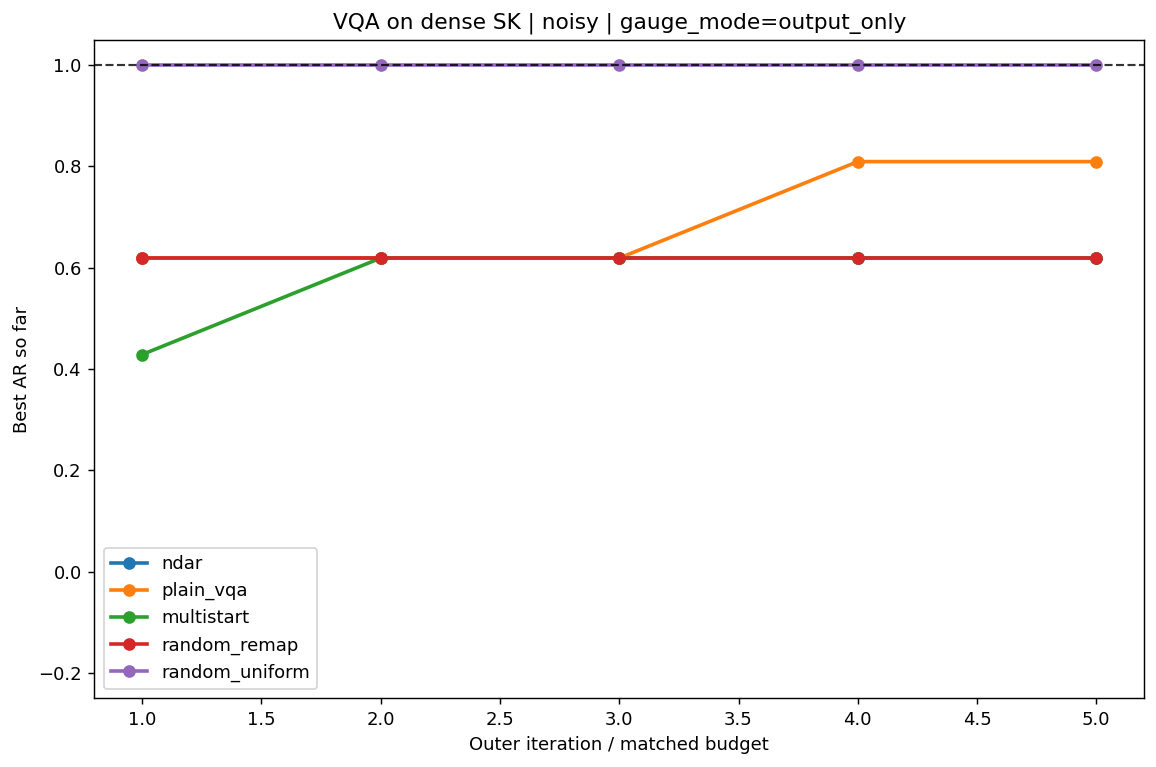

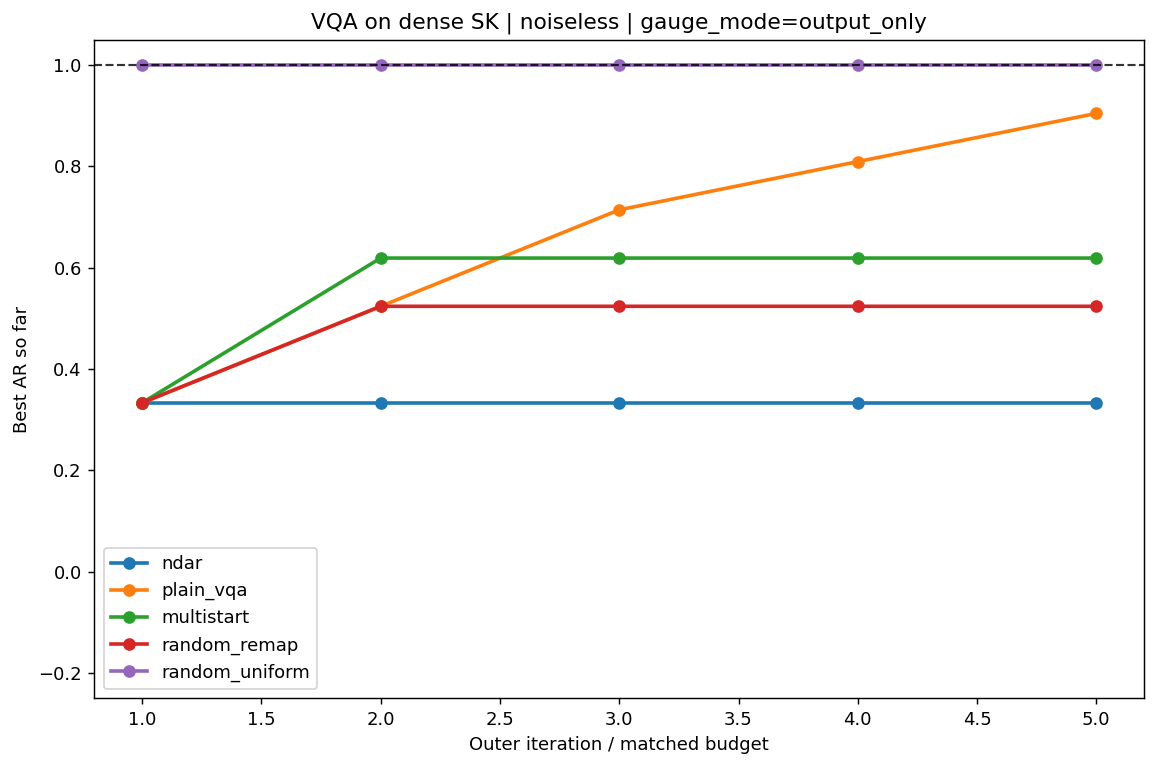

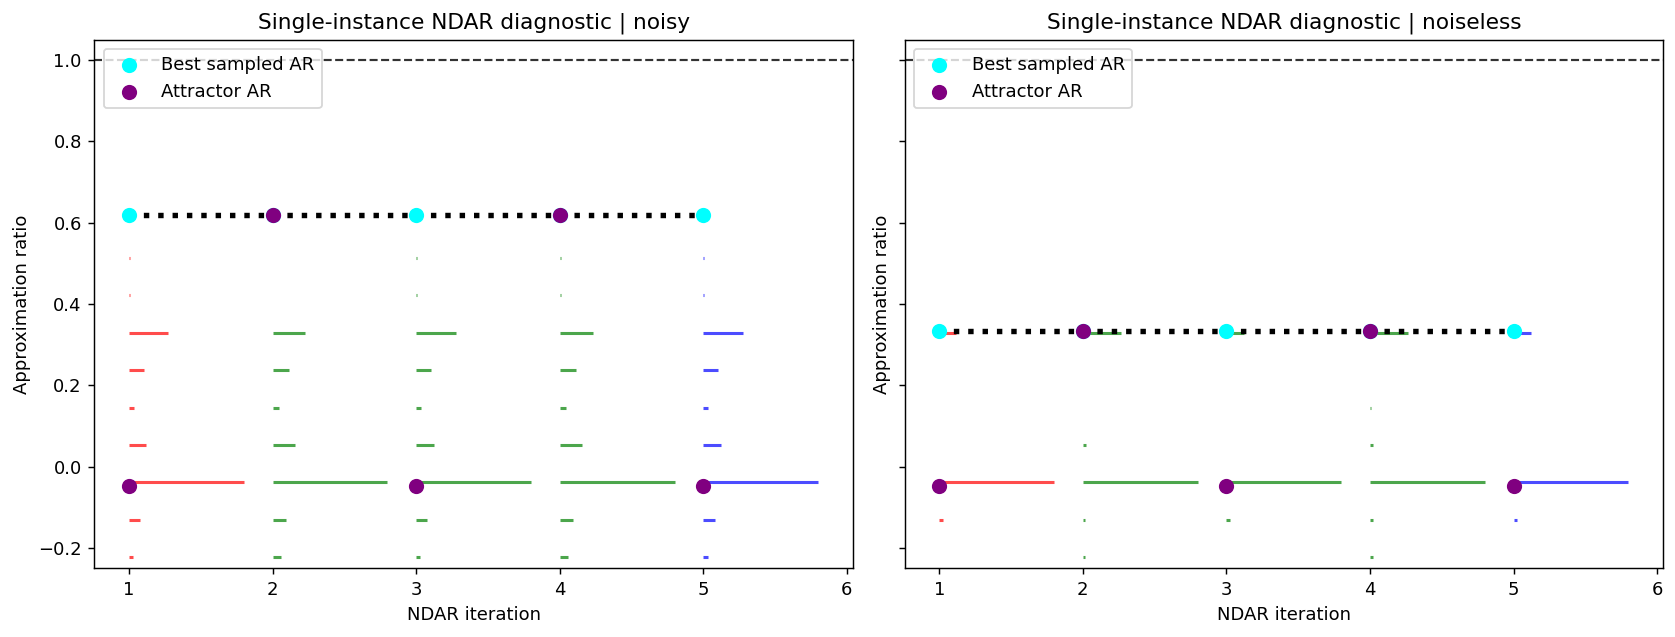

Noise diagnostics: {
  "identity_hw_noisy_mean": 0.0,
  "identity_hw_noisy_std": 0.0,
  "identity_hw_noiseless_mean": 0.0,
  "identity_hw_noiseless_std": 0.0
}


In [18]:

# ======================================================================================
# DRIVERS + PLOTS
# ======================================================================================
def run_one_condition_left(cfg, noisy, root_out_dir):
    condition_name = "noisy" if noisy else "noiseless"
    simulator, transpile_backend = get_simulator_vqa_sk(
        n_qubits=cfg["n_qubits"],
        noisy=noisy,
        cfg=cfg,
    )
    out_dir = ensure_dir(root_out_dir / condition_name)
    df, summary_df = run_left_like(cfg, simulator, transpile_backend, out_dir, condition_name)
    return df, summary_df

def plot_compare_left(df_noisy, df_noiseless, cfg, out_path):
    frac = cfg["top_fracs"][1]
    frac_col = f"optimized_ratio_top_{frac:.6f}"

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)

    for ax, df, title in [
        (axes[0], df_noisy, "Noisy"),
        (axes[1], df_noiseless, "Noiseless"),
    ]:
        ax.scatter(df["attractor_ratio"], df[frac_col], alpha=0.8)
        lo = min(df["attractor_ratio"].min(), df[frac_col].min())
        hi = max(df["attractor_ratio"].max(), df[frac_col].max())
        ax.plot([lo, hi], [lo, hi], "--", color="gray", linewidth=1)
        ax.set_xlabel("Attractor AR")
        ax.set_ylabel(f"Optimized AR (top frac = {frac:.3f})")
        ax.set_title(title + f" | gauge_mode={cfg['gauge_mode']}")
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()

def run_one_instance_right(cfg, noisy, inst_id, out_dir):
    condition_name = "noisy" if noisy else "noiseless"
    simulator, transpile_backend = get_simulator_vqa_sk(
        n_qubits=cfg["n_qubits"], noisy=noisy, cfg=cfg
    )

    seed_instance = cfg["seed"] + 10000 * inst_id
    optimizer_seed = cfg["seed"] + 500000 + inst_id
    problem = build_problem(cfg, seed_instance)

    all_rows = []
    plain_rows = run_plain_vqa(problem, cfg, simulator, transpile_backend, seed_instance, optimizer_seed)
    multistart_rows = run_multistart(problem, cfg, simulator, transpile_backend, seed_instance, optimizer_seed)
    random_remap_rows = run_random_remap(problem, cfg, simulator, transpile_backend, seed_instance, optimizer_seed)
    ndar_rows, ratio_distributions, best_ratios, attractor_ratios = run_ndar(
        problem, cfg, simulator, transpile_backend, seed_instance, optimizer_seed
    )
    random_uniform_rows = run_random_uniform(problem, cfg, seed_instance)

    for rows in [plain_rows, multistart_rows, random_remap_rows, ndar_rows, random_uniform_rows]:
        for row in rows:
            row["condition"] = condition_name
            row["instance_id"] = inst_id
            all_rows.append(row)

    df_inst = pd.DataFrame(all_rows)
    return df_inst, {
        "problem": problem,
        "ratio_distributions": ratio_distributions,
        "best_ratios": best_ratios,
        "attractor_ratios": attractor_ratios,
    }

def aggregate_summary(df_all):
    grouped = (
        df_all.groupby(["condition", "method", "outer_iter"], as_index=False)
        .agg(
            mean_ratio=("best_ratio_so_far", "mean"),
            std_ratio=("best_ratio_so_far", "std"),
            min_ratio=("best_ratio_so_far", "min"),
            max_ratio=("best_ratio_so_far", "max"),
        )
    )
    grouped["std_ratio"] = grouped["std_ratio"].fillna(0.0)
    return grouped

def plot_right_panel_like(df_summary, out_path, condition_name):
    plt.figure(figsize=(9, 6))
    for method in ["ndar", "plain_vqa", "multistart", "random_remap", "random_uniform"]:
        sub = df_summary[
            (df_summary["condition"] == condition_name) &
            (df_summary["method"] == method)
        ].sort_values("outer_iter")
        if len(sub) == 0:
            continue
        x = sub["outer_iter"].to_numpy()
        y = sub["mean_ratio"].to_numpy()
        s = sub["std_ratio"].to_numpy()
        plt.plot(x, y, marker="o", linewidth=2, label=method)
        plt.fill_between(x, y - s, y + s, alpha=0.15)

    plt.axhline(1.0, color="black", linestyle="--", linewidth=1.2, alpha=0.8)
    plt.xlabel("Outer iteration / matched budget")
    plt.ylabel("Best AR so far")
    plt.title(f"VQA on dense SK | {condition_name} | gauge_mode={CONFIG['gauge_mode']}")
    plt.ylim(-0.25, 1.05)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()

def plot_side_histograms(ax, x_positions, ratio_distributions, best_ratios, attractor_ratios, title):
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1.2, alpha=0.8)
    for idx, (x0, ratios) in enumerate(zip(x_positions, ratio_distributions)):
        ratios = np.asarray(ratios, dtype=float)
        bins = np.linspace(-0.3, 1.05, 45)
        hist, edges = np.histogram(ratios, bins=bins)
        centers = 0.5 * (edges[:-1] + edges[1:])

        if hist.max() > 0:
            widths = 0.8 * hist / hist.max()
        else:
            widths = np.zeros_like(hist, dtype=float)

        if idx == 0:
            color = "red"
        elif idx == len(x_positions) - 1:
            color = "blue"
        else:
            color = "green"

        for c, w in zip(centers, widths):
            if w > 0:
                ax.hlines(y=c, xmin=x0, xmax=x0 + w, color=color, alpha=0.7, linewidth=1.7)

    ax.step(x_positions, best_ratios, where="mid", color="black", linestyle=":", linewidth=3)
    ax.scatter(x_positions, best_ratios, color="cyan", s=55, label="Best sampled AR", zorder=5)
    ax.scatter(x_positions, attractor_ratios, color="purple", s=55, label="Attractor AR", zorder=5)

    ax.set_xlabel("NDAR iteration")
    ax.set_ylabel("Approximation ratio")
    ax.set_title(title)
    ax.set_ylim(-0.25, 1.05)
    ax.legend(loc="upper left")

def run_all(cfg):
    root_out_dir = ensure_dir(cfg["out_dir"])
    save_json(cfg, root_out_dir / "config_root.json")

    left_outputs = {}
    if cfg["run_left_panel"]:
        for noisy in [True, False]:
            cond = "noisy" if noisy else "noiseless"
            df, summary_df = run_one_condition_left(cfg, noisy, root_out_dir)
            left_outputs[cond] = (df, summary_df)

        plot_compare_left(
            left_outputs["noisy"][0],
            left_outputs["noiseless"][0],
            cfg,
            root_out_dir / "left_compare_top20.png",
        )

    right_outputs = {}
    if cfg["run_right_panel"]:
        all_rows = []
        diag_cache = {}
        for noisy in [True, False]:
            cond = "noisy" if noisy else "noiseless"
            diag_cache[cond] = None
            inst_iter = tqdm(range(cfg["n_instances"]), desc=f"{cond} right instances")
            for inst_id in inst_iter:
                df_inst, diag = run_one_instance_right(cfg, noisy, inst_id, root_out_dir)
                all_rows.append(df_inst)
                if inst_id == 0:
                    diag_cache[cond] = diag

        df_all = pd.concat(all_rows, ignore_index=True)
        df_all.to_csv(root_out_dir / "right_all_trajectories.csv", index=False)

        df_summary = aggregate_summary(df_all)
        df_summary.to_csv(root_out_dir / "right_summary_trajectories.csv", index=False)

        plot_right_panel_like(
            df_summary,
            root_out_dir / "right_panel_like_noisy.png",
            condition_name="noisy",
        )
        plot_right_panel_like(
            df_summary,
            root_out_dir / "right_panel_like_noiseless.png",
            condition_name="noiseless",
        )

        right_outputs["all"] = df_all
        right_outputs["summary"] = df_summary
        right_outputs["diag"] = diag_cache

    if cfg["run_single_instance_diag"] and cfg["run_right_panel"]:
        fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
        for ax, cond in zip(axes, ["noisy", "noiseless"]):
            diag = right_outputs["diag"][cond]
            if diag is None:
                continue
            x_ndar = np.arange(1, len(diag["ratio_distributions"]) + 1)
            plot_side_histograms(
                ax=ax,
                x_positions=x_ndar,
                ratio_distributions=diag["ratio_distributions"],
                best_ratios=diag["best_ratios"],
                attractor_ratios=diag["attractor_ratios"],
                title=f"Single-instance NDAR diagnostic | {cond}",
            )
        plt.tight_layout()
        plt.savefig(root_out_dir / "single_instance_ndar_diagnostic.png", dpi=200)
        plt.show()

    diag_noisy = identity_hamming_weight_diagnostic(cfg, noisy=True, shots=2000)
    diag_noiseless = identity_hamming_weight_diagnostic(cfg, noisy=False, shots=2000)
    diagnostics = {
        "identity_hw_noisy_mean": diag_noisy["mean_hw"],
        "identity_hw_noisy_std": diag_noisy["std_hw"],
        "identity_hw_noiseless_mean": diag_noiseless["mean_hw"],
        "identity_hw_noiseless_std": diag_noiseless["std_hw"],
    }
    save_json(diagnostics, root_out_dir / "noise_diagnostics.json")
    print("Noise diagnostics:", json.dumps(diagnostics, indent=2))

    return left_outputs, right_outputs

left_outputs, right_outputs = run_all(CONFIG)


In [19]:

# Quick view of the main left-panel correlation summaries
if CONFIG["run_left_panel"]:
    print("NOISY")
    display(left_outputs["noisy"][1])
    print("NOISELESS")
    display(left_outputs["noiseless"][1])

# Quick view of the main right-panel summary table
if CONFIG["run_right_panel"]:
    display(right_outputs["summary"].head(20))


NOISY


,quantile,pearson_r,spearman_rho,mean_attractor_ratio,mean_optimized_ratio
0,1.000000,1.0,1.0,0.238095,0.015714
1,0.195312,1.0,1.0,0.238095,0.333333
2,0.003906,1.0,1.0,0.238095,0.571429


NOISELESS


,quantile,pearson_r,spearman_rho,mean_attractor_ratio,mean_optimized_ratio
0,1.000000,1.0,1.0,0.238095,-0.011905
1,0.195312,1.0,1.0,0.238095,0.204762
2,0.003906,NaN,NaN,0.238095,0.333333


,condition,method,outer_iter,mean_ratio,std_ratio,min_ratio,max_ratio
0,noiseless,multistart,1,0.333333,0.0,0.333333,0.333333
1,noiseless,multistart,2,0.619048,0.0,0.619048,0.619048
2,noiseless,multistart,3,0.619048,0.0,0.619048,0.619048
3,noiseless,multistart,4,0.619048,0.0,0.619048,0.619048
4,noiseless,multistart,5,0.619048,0.0,0.619048,0.619048
5,noiseless,ndar,1,0.333333,0.0,0.333333,0.333333
6,noiseless,ndar,2,0.333333,0.0,0.333333,0.333333
7,noiseless,ndar,3,0.333333,0.0,0.333333,0.333333
8,noiseless,ndar,4,0.333333,0.0,0.333333,0.333333
9,noiseless,ndar,5,0.333333,0.0,0.333333,0.333333
